In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numbers
import seaborn as sns
from sklearn.model_selection import train_test_split
import xgboost as xgb

Churn Rate Analysis
1. The Problem: Customer retention fell off
2. The Goal: Find out the signs that are linked to customer cancelling subscription
3. The Plan: Use churn as the target column, the features aris everything else other than customer ID

In [2]:
# Import Dataset
df_train = pd.read_csv('data/customer_churn_dataset-training-master.csv')
df_test = pd.read_csv('data/customer_churn_dataset-testing-master.csv')

pd.set_option("display.max_column", None)
pd.set_option('display.width', 1000)

df_test.head()

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,1,22,Female,25,14,4,27,Basic,Monthly,598,9,1
1,2,41,Female,28,28,7,13,Standard,Monthly,584,20,0
2,3,47,Male,27,10,2,29,Premium,Annual,757,21,0
3,4,35,Male,9,12,5,17,Premium,Quarterly,232,18,0
4,5,53,Female,58,24,9,2,Standard,Annual,533,18,0


EDA Phase:
- Search for distributions
- Search for nulls
- Keep outliers since it might help us take in the extreme users

In [3]:
# Check for any "Missing Values" and "Data Types"?
df_train.info()

# Statistical Values
# Helps us understand possible outliers, high and low values, and the usual monthly charge from mean
df_train.describe(include=['object', 'bool'])
df_train.describe(include=['float', 'int'])

<class 'pandas.DataFrame'>
RangeIndex: 440833 entries, 0 to 440832
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   CustomerID         440832 non-null  float64
 1   Age                440832 non-null  float64
 2   Gender             440832 non-null  str    
 3   Tenure             440832 non-null  float64
 4   Usage Frequency    440832 non-null  float64
 5   Support Calls      440832 non-null  float64
 6   Payment Delay      440832 non-null  float64
 7   Subscription Type  440832 non-null  str    
 8   Contract Length    440832 non-null  str    
 9   Total Spend        440832 non-null  float64
 10  Last Interaction   440832 non-null  float64
 11  Churn              440832 non-null  float64
dtypes: float64(9), str(3)
memory usage: 40.4 MB


/var/folders/rc/kbwf9qc13ds2_f_927hh85dc0000gn/T/ipykernel_38872/2388648268.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df_train.describe(include=['object', 'bool'])


,CustomerID,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn
count,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000
mean,225398.667955,39.373153,31.256336,15.807494,3.604437,12.965722,631.616223,14.480868,0.567107
std,129531.918550,12.442369,17.255727,8.586242,3.070218,8.258063,240.803001,8.596208,0.495477
min,2.000000,18.000000,1.000000,1.000000,0.000000,0.000000,100.000000,1.000000,0.000000
25%,113621.750000,29.000000,16.000000,9.000000,1.000000,6.000000,480.000000,7.000000,0.000000
50%,226125.500000,39.000000,32.000000,16.000000,3.000000,12.000000,661.000000,14.000000,1.000000
75%,337739.250000,48.000000,46.000000,23.000000,6.000000,19.000000,830.000000,22.000000,1.000000
max,449999.000000,65.000000,60.000000,30.000000,10.000000,30.000000,1000.000000,30.000000,1.000000


Distribution

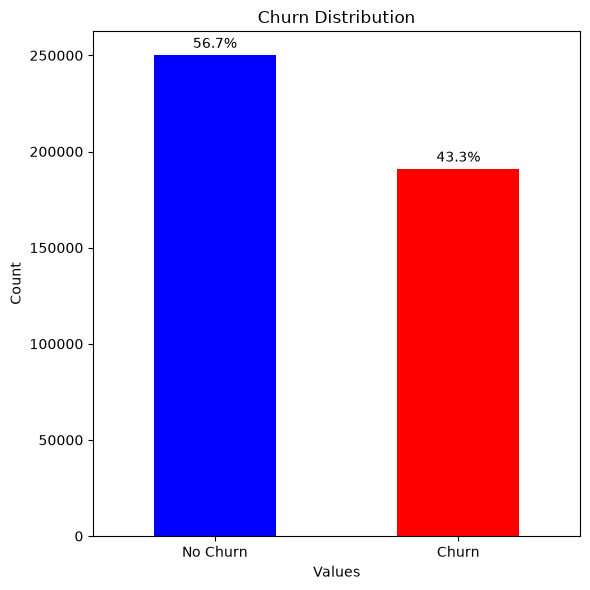

In [4]:
# Understanding the Target Column (Churt)
count = df_train['Churn'].value_counts()

# Churn Distribution Graph
plt.figure(figsize=(6, 6))
ax = count.plot(kind='bar', color=['blue', 'red'])

plt.title('Churn Distribution')
plt.xlabel('Values')
plt.ylabel('Count')
plt.xticks(ticks=[0, 1], labels=['No Churn', 'Churn'], rotation=0)

total_value = len(df_train)
# For Pct Label
for cont in ax.containers:
    # Calculate the pct
    pct_labels=[]
    for v in cont:
        height = v.get_height()
        pct_labels.append(f'{height / total_value:.1%}')
    ax.bar_label(cont, labels=pct_labels, label_type='edge', padding=3) 

plt.tight_layout()
plt.show()


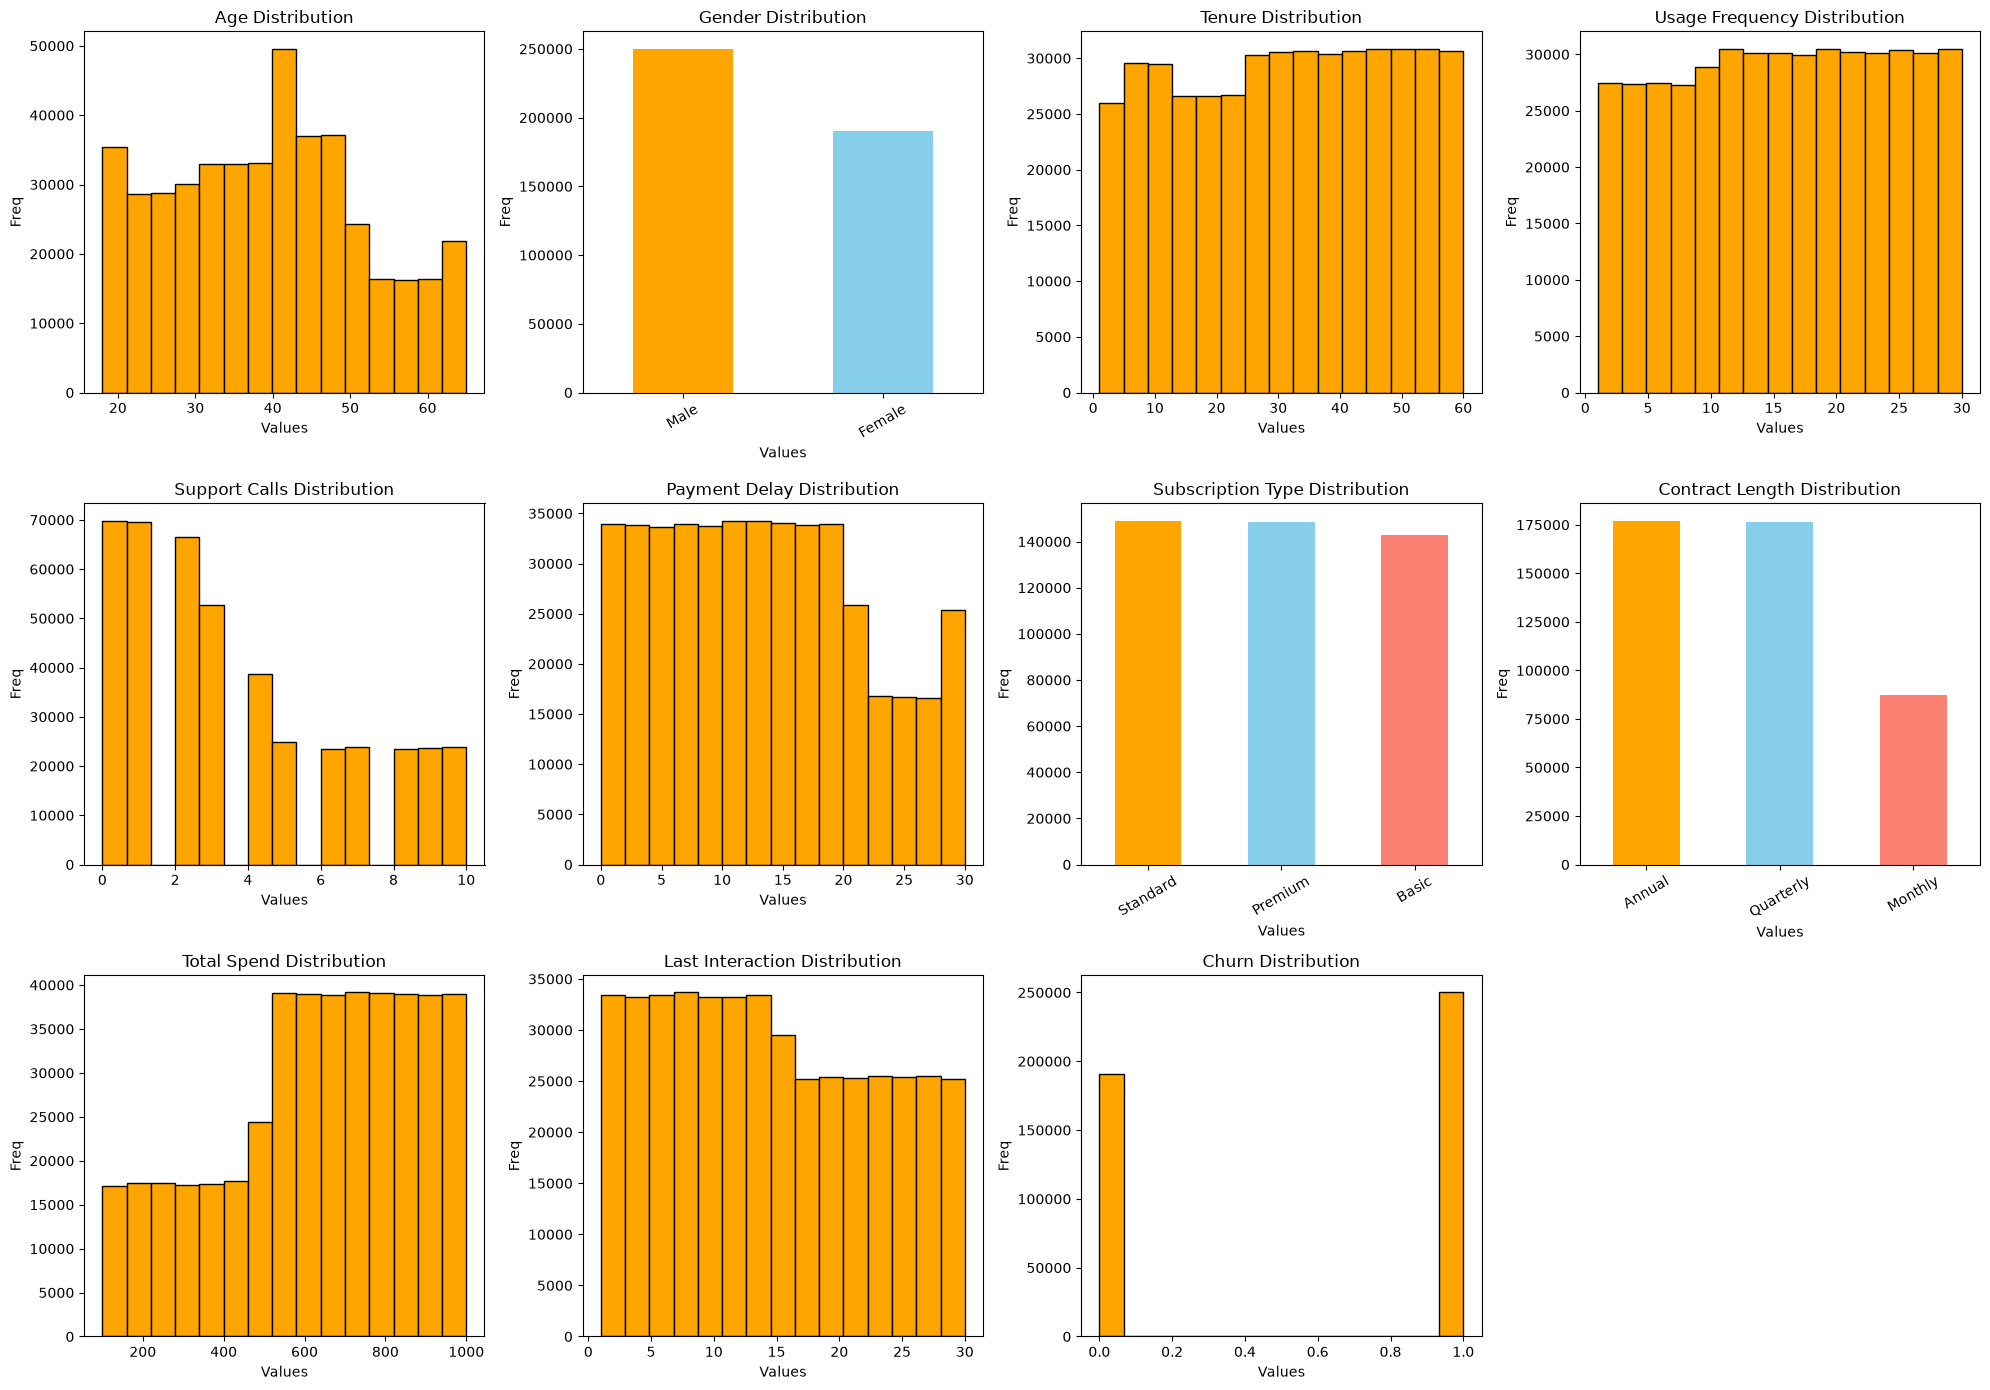

In [5]:
# Feature Distribution
features = ['Age', 'Gender', 'Tenure', 'Usage Frequency', 'Support Calls', 'Payment Delay', 'Subscription Type', 'Contract Length', 'Total Spend', 'Last Interaction', 'Churn']

fig, axes = plt.subplots(nrows=3, ncols=4, figsize=(20, 14))
axes = axes.flatten()

for i, f in enumerate(features):
    ax=axes[i]

    if df_train[f].dtype.kind in 'biuf':
        ax.hist(df_train[f], bins=15, color='orange', edgecolor='black')
    else:
        count = df_train[f].value_counts()
        count.plot(ax=ax, kind='bar', color=['orange', 'skyblue', 'salmon'])
        ax.tick_params(axis='x', labelrotation=30)

    ax.set_title(f'{f} Distribution')
    ax.set_xlabel('Values')
    ax.set_ylabel('Freq')

for n in range(len(features), len(axes)):
    fig.delaxes(axes[n])

plt.tight_layout()
plt.show()


In [6]:
# Correlation Mapping
# Encoding non numeric datatypes into numeric
# This method prevents creating a new column for every instance like "Premium", "Normal" and still have them
# in one column which is "subscription"
encode_df = df_train[features].copy()
for col in encode_df.select_dtypes(include=['object']).columns:
    encode_df[col] = encode_df[col].astype('category').cat.codes

# Calculate feature correlation with target
target_corr = encode_df.corr()['Churn'].sort_values(ascending=False).drop('Churn')
print(f"Feature to Target Correlation:\n\n{target_corr}\n")

Feature to Target Correlation:

Support Calls        0.574267
Payment Delay        0.312129
Age                  0.218394
Last Interaction     0.149616
Contract Length     -0.000093
Subscription Type   -0.017181
Usage Frequency     -0.046101
Tenure              -0.051919
Gender              -0.175395
Total Spend         -0.429355
Name: Churn, dtype: float64



/var/folders/rc/kbwf9qc13ds2_f_927hh85dc0000gn/T/ipykernel_38872/3212863589.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in encode_df.select_dtypes(include=['object']).columns:


Correlation Matrix
1. Feature to feature using pearson
2. Feature to target
3. Then we classify the baseline and which features passed each baseline

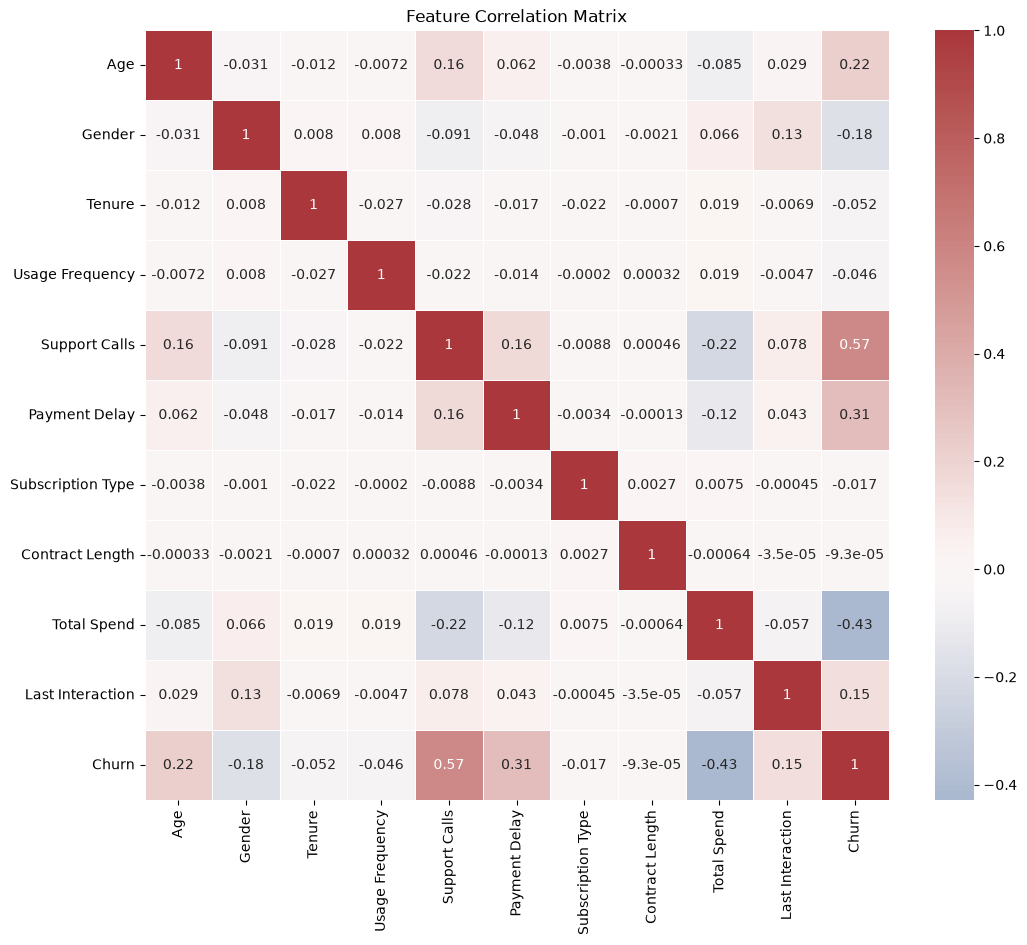

In [7]:
# Calculate feature correlation with each features
plt.figure(figsize=(12, 10))
sns.heatmap(
    encode_df.corr(method='pearson'),
    annot=True,
    cmap="vlag",
    center=0,
    linewidths=0.5
)
plt.title('Feature Correlation Matrix')
plt.show()

# print(f"Feature to Feature Correlation:\n\n{feature_corr}\n")

Data Preprocessing
1. Clean the Nulls
2. Clean the outliers (if necessary)
3. Encode the nonnumeric datatypes into Numeric
4. Split the features and the target and drop unwanted columns on the analysis (e.g, customerID)

In [8]:
# Check first is there any null values?
encode_df.info()

# Drop the rows where the 'Churn' target is missing
encode_df = encode_df.dropna()
# No Nulls that mean it needs no null handling


<class 'pandas.DataFrame'>
RangeIndex: 440833 entries, 0 to 440832
Data columns (total 11 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Age                440832 non-null  float64
 1   Gender             440833 non-null  int8   
 2   Tenure             440832 non-null  float64
 3   Usage Frequency    440832 non-null  float64
 4   Support Calls      440832 non-null  float64
 5   Payment Delay      440832 non-null  float64
 6   Subscription Type  440833 non-null  int8   
 7   Contract Length    440833 non-null  int8   
 8   Total Spend        440832 non-null  float64
 9   Last Interaction   440832 non-null  float64
 10  Churn              440832 non-null  float64
dtypes: float64(8), int8(3)
memory usage: 28.2 MB


In [9]:
# Remove Customer_ID
x = encode_df.drop(columns=['Churn'])
y = encode_df['Churn'].astype(int)

# Split the target and the feature column
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)

print(y.unique())

[1 0]


In [10]:
# Train the model
model = xgb.XGBClassifier(
    n_estimators = 100,
    max_depth = 5,
    learning_rate = 0.1
)

model.fit(x_train, y_train)

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [11]:
# Prediction
y_pred = model.predict(x_test)

# Probabilies
y_prob = model.predict_proba(x_test)[:, 1]

print(y_pred[:10])
print(y_prob[:10])

[1 1 1 1 0 0 0 0 1 1]
[0.99944085 0.9999685  0.9997756  0.9999355  0.00414738 0.00856673
 0.00273542 0.03121966 0.9603379  0.99999714]
